# YOLOv4-p6 物体検出サンプル

このNotebookでは、OpenCV DNNでDarknet形式のYOLOv4-p6モデルを読み込み、物体検出を行います。Darknet本体は使用しません。

最新のUltralytics YOLO11はAGPL-3.0ライセンスで提供されています。このNotebookでは、そのライセンス条件を避けて利用したいケースを想定し、YOLOv4-p6を採用しています。モデルファイルの取得元と利用条件は、同梱のREADMEを確認してください。

## 1. 必要なライブラリのインポート

In [12]:
from pathlib import Path
from urllib.request import urlopen
import shutil

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

## 2. YOLOv4-p6モデルの取得

初回実行時に、公式配布元から設定・重み・COCOクラス名を取得します。重みは約487MBです。

In [13]:
MODEL_DIR = Path("models/yolov4-p6")
MODEL_FILES = {
    "config": (
        MODEL_DIR / "yolov4-p6.cfg",
        "https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov4-p6.cfg",
    ),
    "weights": (
        MODEL_DIR / "yolov4-p6.weights",
        "https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v4_pre/yolov4-p6.weights",
    ),
    "classes": (
        MODEL_DIR / "coco.names",
        "https://raw.githubusercontent.com/AlexeyAB/darknet/master/data/coco.names",
    ),
}

def download_if_missing(destination: Path, url: str) -> None:
    if destination.exists() and destination.stat().st_size > 0:
        print(f"Using existing file: {destination}")
        return

    destination.parent.mkdir(parents=True, exist_ok=True)
    temporary = destination.with_suffix(destination.suffix + ".part")
    temporary.unlink(missing_ok=True)
    print(f"Downloading {destination.name} ...")
    try:
        with urlopen(url, timeout=60) as response, temporary.open("wb") as output:
            shutil.copyfileobj(response, output)
        temporary.replace(destination)
    except Exception:
        temporary.unlink(missing_ok=True)
        raise

for path, url in MODEL_FILES.values():
    download_if_missing(path, url)

config_path = MODEL_FILES["config"][0]
weights_path = MODEL_FILES["weights"][0]
classes_path = MODEL_FILES["classes"][0]

Using existing file: models/yolov4-p6/yolov4-p6.cfg
Using existing file: models/yolov4-p6/yolov4-p6.weights
Using existing file: models/yolov4-p6/coco.names


## 3. 入力画像とモデルの読み込み

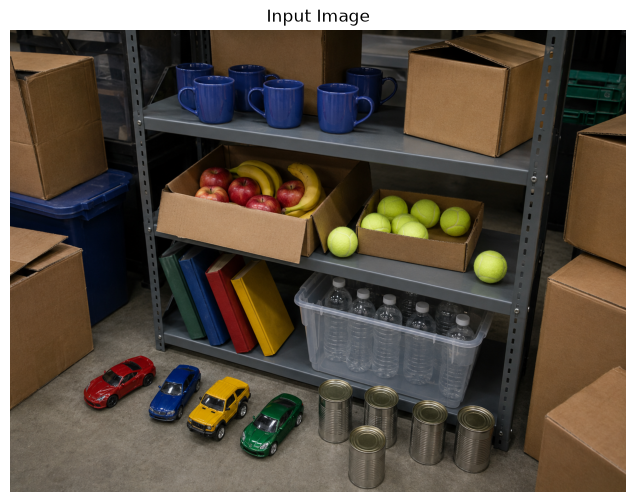

Image size: 1448 x 1086
Loaded 80 COCO classes


In [14]:
image_path = Path("../assets/test1.png")
image = cv2.imread(str(image_path))
if image is None:
    raise FileNotFoundError(f"Input image was not found or could not be read: {image_path}")

with classes_path.open(encoding="utf-8") as file:
    class_names = [line.strip() for line in file if line.strip()]

net = cv2.dnn.readNetFromDarknet(str(config_path), str(weights_path))

plt.figure(figsize=(10, 6))
plt.imshow(Image.open(image_path))
plt.axis("off")
plt.title("Input Image")
plt.show()

print(f"Image size: {image.shape[1]} x {image.shape[0]}")
print(f"Loaded {len(class_names)} COCO classes")

## 4. 物体検出の実行

confidence 0.5未満の候補を除外し、NMS閾値0.4で重複する枠を統合します。

In [15]:
CONFIDENCE_THRESHOLD = 0.5
NMS_THRESHOLD = 0.4

height, width = image.shape[:2]
blob = cv2.dnn.blobFromImage(
    image, scalefactor=1 / 255.0, size=(1280, 1280), swapRB=True, crop=False
)
net.setInput(blob)
outputs = net.forward(net.getUnconnectedOutLayersNames())

boxes, confidences, class_ids = [], [], []
for output in outputs:
    for detection in output:
        objectness = float(detection[4])
        scores = detection[5:]
        class_id = int(np.argmax(scores))
        confidence = objectness * float(scores[class_id])
        if confidence < CONFIDENCE_THRESHOLD:
            continue

        center_x, center_y, box_width, box_height = detection[:4] * np.array([width, height, width, height])
        x = int(center_x - box_width / 2)
        y = int(center_y - box_height / 2)
        boxes.append([x, y, int(box_width), int(box_height)])
        confidences.append(confidence)
        class_ids.append(class_id)

indices = cv2.dnn.NMSBoxes(boxes, confidences, CONFIDENCE_THRESHOLD, NMS_THRESHOLD)
selected_indices = np.array(indices).reshape(-1).tolist() if len(indices) else []
detections = []
for index in selected_indices:
    x, y, box_width, box_height = boxes[index]
    x1, y1 = max(0, x), max(0, y)
    x2, y2 = min(width, x + box_width), min(height, y + box_height)
    detections.append({
        "class": class_names[class_ids[index]],
        "confidence": confidences[index],
        "bbox": [x1, y1, x2, y2],
    })

print(f"Detected {len(detections)} objects")

Detected 19 objects


## 5. 検出結果の可視化と集計

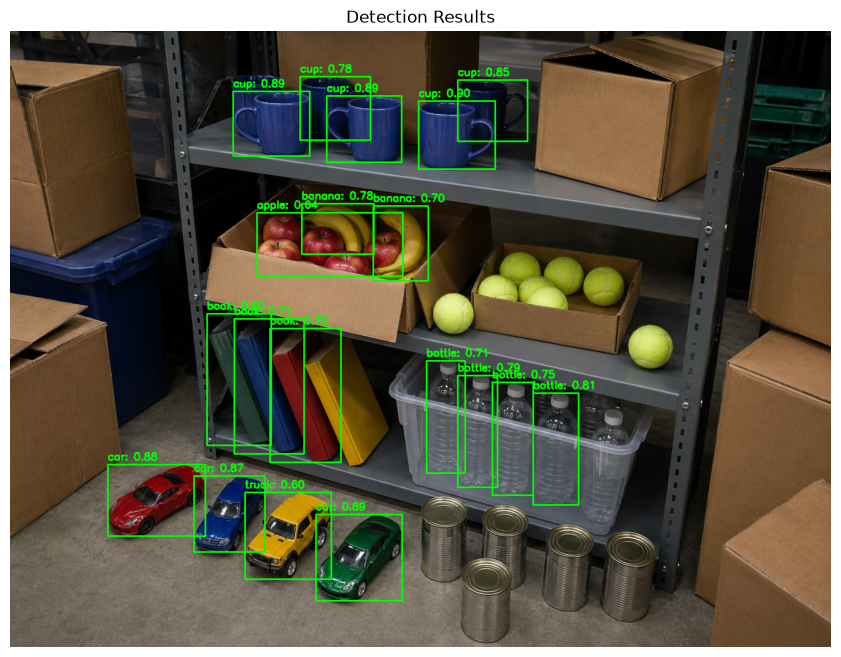

### 検出された物体の数


,クラス,検出数
5,cup,5
3,bottle,4
2,book,3
4,car,3
1,banana,2
0,apple,1
6,truck,1


合計: 19 個の物体を検出
### 検出された物体の詳細情報


,class,confidence,bbox
0,cup,0.901154,"[720, 123, 855, 243]"
1,cup,0.893167,"[558, 114, 690, 231]"
2,cup,0.889628,"[393, 106, 528, 220]"
3,car,0.885063,"[539, 852, 691, 1004]"
4,car,0.881888,"[172, 764, 344, 890]"
5,car,0.874077,"[324, 784, 449, 918]"
6,cup,0.852284,"[789, 86, 912, 194]"
7,bottle,0.811293,"[922, 638, 1002, 835]"
8,bottle,0.792185,"[789, 607, 859, 804]"
9,cup,0.781113,"[511, 80, 635, 192]"


In [16]:
result_image = image.copy()
for detection in detections:
    x1, y1, x2, y2 = detection["bbox"]
    label = f"{detection['class']}: {detection['confidence']:.2f}"
    cv2.rectangle(result_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(result_image, label, (x1, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Detection Results")
plt.show()

df = pd.DataFrame(detections, columns=["class", "confidence", "bbox"])
df_counts = (
    df.groupby("class").size().reset_index(name="検出数").sort_values("検出数", ascending=False)
    if not df.empty
    else pd.DataFrame(columns=["class", "検出数"])
)

print("### 検出された物体の数")
display(df_counts.rename(columns={"class": "クラス"}))
print(f"合計: {len(df)} 個の物体を検出")
print("### 検出された物体の詳細情報")
display(df)